# N1 — Underlying EDA: HYDROGEL_PACK and VELVETFRUIT_EXTRACT

**Goal.** Characterize the price processes of the two delta-1 products in R3 to decide between
market-making, mean-reversion, and directional strategies.

**Products.** HYDROGEL_PACK (limit 200) and VELVETFRUIT_EXTRACT (VEV, limit 200, also the
underlying for the 10 vouchers).

**Data.** 3 historical days at 100ms tick resolution (~10k ticks/day). Day-0 corresponds to TTE=8d,
day-1 to 7d, day-2 to 6d for the vouchers, but the underlying processes themselves are model-free
here.

**Convention.** Mid-price = 0.5 (best_bid + best_ask). Tick log-returns
$r_t = \log(m_t / m_{t-1})$ are computed *within* a day; cross-day boundaries are dropped so we do
not embed the overnight gap into the autocorrelation estimates.

## 0. Imports and paths

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf

DATA = Path("/Users/samuelshi/IMC-Prosperity-2026-personal/R3/r3_datacap")
CACHE = Path("/Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache")
CACHE.mkdir(parents=True, exist_ok=True)

DAYS = [0, 1, 2]
PRODUCTS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(0)


## 1. Load and concatenate

Each historical day has ~10k timestamps in [0, 1_000_000) at 100-tick spacing. We build a single
continuous series per product by re-indexing each day onto a global tick `t = day * 1_000_000 + ts`,
preserving day boundaries for visual marking but treating each day as an independent sample for
return-based statistics.

In [2]:
def load_prices(day):
    p = DATA / f"prices_round_3_day_{day}.csv"
    df = pd.read_csv(p, sep=";")
    return df

frames = []
for d in DAYS:
    raw = load_prices(d)
    sub = raw[raw["product"].isin(PRODUCTS)].copy()
    sub["day"] = d
    frames.append(sub)

prices = pd.concat(frames, ignore_index=True)
prices["t_global"] = prices["day"] * 1_000_000 + prices["timestamp"]
prices = prices.sort_values(["product", "t_global"]).reset_index(drop=True)
print("rows:", len(prices))
prices.head(3)


rows: 60000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t_global
0,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0
1,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,100
2,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,200


## 2. Sanity check and cleaning

We check, per product per day:
- row count (should be 10,000)
- fraction of rows where the file's `mid_price` is NaN
- fraction of rows missing best bid OR best ask (one-sided book)
- whether `mid_price` matches our recomputed `0.5*(best_bid+best_ask)` (within 1e-6)

Cleaning rule: drop rows with one-sided book; otherwise keep `mid_price` as-is.

In [3]:
def sanity(df):
    out = []
    for (prod, day), g in df.groupby(["product", "day"]):
        n = len(g)
        nan_mid = g["mid_price"].isna().mean()
        one_sided = ((g["bid_price_1"].isna()) | (g["ask_price_1"].isna())).mean()
        # Recomputed mid match
        recomputed = 0.5 * (g["bid_price_1"] + g["ask_price_1"])
        match = np.isclose(recomputed, g["mid_price"], equal_nan=True).mean()
        out.append(dict(product=prod, day=day, n=n, frac_nan_mid=nan_mid,
                        frac_one_sided=one_sided, frac_mid_match=match))
    return pd.DataFrame(out)

sanity_df = sanity(prices)
sanity_df


,product,day,n,frac_nan_mid,frac_one_sided,frac_mid_match
0,HYDROGEL_PACK,0,10000,0.0,0.0,1.0
1,HYDROGEL_PACK,1,10000,0.0,0.0,1.0
2,HYDROGEL_PACK,2,10000,0.0,0.0,1.0
3,VELVETFRUIT_EXTRACT,0,10000,0.0,0.0,1.0
4,VELVETFRUIT_EXTRACT,1,10000,0.0,0.0,1.0
5,VELVETFRUIT_EXTRACT,2,10000,0.0,0.0,1.0


In [4]:
# Drop one-sided rows; recompute mid for safety.
clean = prices.dropna(subset=["bid_price_1", "ask_price_1"]).copy()
clean["mid"] = 0.5 * (clean["bid_price_1"] + clean["ask_price_1"])
clean["spread"] = clean["ask_price_1"] - clean["bid_price_1"]
print("kept:", len(clean), "rows")
clean.groupby("product")["spread"].describe()[["min", "25%", "50%", "75%", "max"]]


kept: 60000 rows


,min,25%,50%,75%,max
product,,,,,
HYDROGEL_PACK,7.0,16.0,16.0,16.0,17.0
VELVETFRUIT_EXTRACT,1.0,5.0,5.0,5.0,6.0


## 3. Mid-price series and tick log-returns

Vertical dashed lines mark day boundaries. Returns are computed within each (product, day) group so
the overnight discontinuity is not folded into $r_t$.

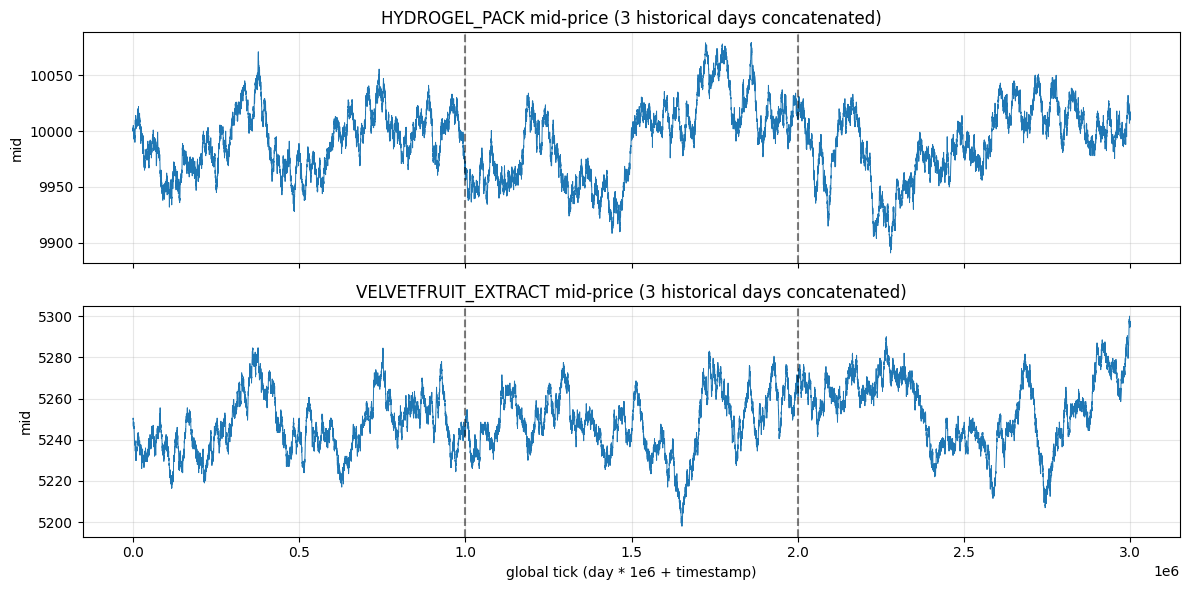

In [5]:
def split_by_product(df):
    return {p: g.reset_index(drop=True) for p, g in df.groupby("product")}

series = split_by_product(clean)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, prod in zip(axes, PRODUCTS):
    g = series[prod]
    ax.plot(g["t_global"].values, g["mid"].values, lw=0.7)
    for d in DAYS[1:]:
        ax.axvline(d * 1_000_000, color="k", ls="--", alpha=0.5)
    ax.set_title(f"{prod} mid-price (3 historical days concatenated)")
    ax.set_ylabel("mid")
axes[-1].set_xlabel("global tick (day * 1e6 + timestamp)")
plt.tight_layout()
plt.show()


In [6]:
# Tick log-returns (within-day only)
def tick_log_returns(g):
    g = g.sort_values("t_global").copy()
    out = []
    for d, gd in g.groupby("day"):
        r = np.log(gd["mid"].values[1:] / gd["mid"].values[:-1])
        out.append(pd.DataFrame({
            "t_global": gd["t_global"].values[1:],
            "day": d,
            "r": r,
        }))
    return pd.concat(out, ignore_index=True)

rets = {p: tick_log_returns(series[p]) for p in PRODUCTS}
for p in PRODUCTS:
    r = rets[p]["r"].values
    print(f"{p}: n={len(r)}, mean={r.mean():.2e}, std={r.std():.2e}, "
          f"min={r.min():.2e}, max={r.max():.2e}")


HYDROGEL_PACK: n=29997, mean=4.66e-08, std=2.17e-04, min=-1.15e-03, max=1.16e-03
VELVETFRUIT_EXTRACT: n=29997, mean=2.69e-07, std=2.15e-04, min=-1.05e-03, max=9.56e-04


## 4. Return distribution and tail behaviour

Excess kurtosis $> 0$ means heavier tails than a Gaussian. Fraction $|r|>5\sigma$ is the empirical
analogue: under a Gaussian this is $\sim 5.7\times10^{-7}$, so anything above ~1e-4 is a tail
problem for any strategy that assumes IID Gaussian returns.

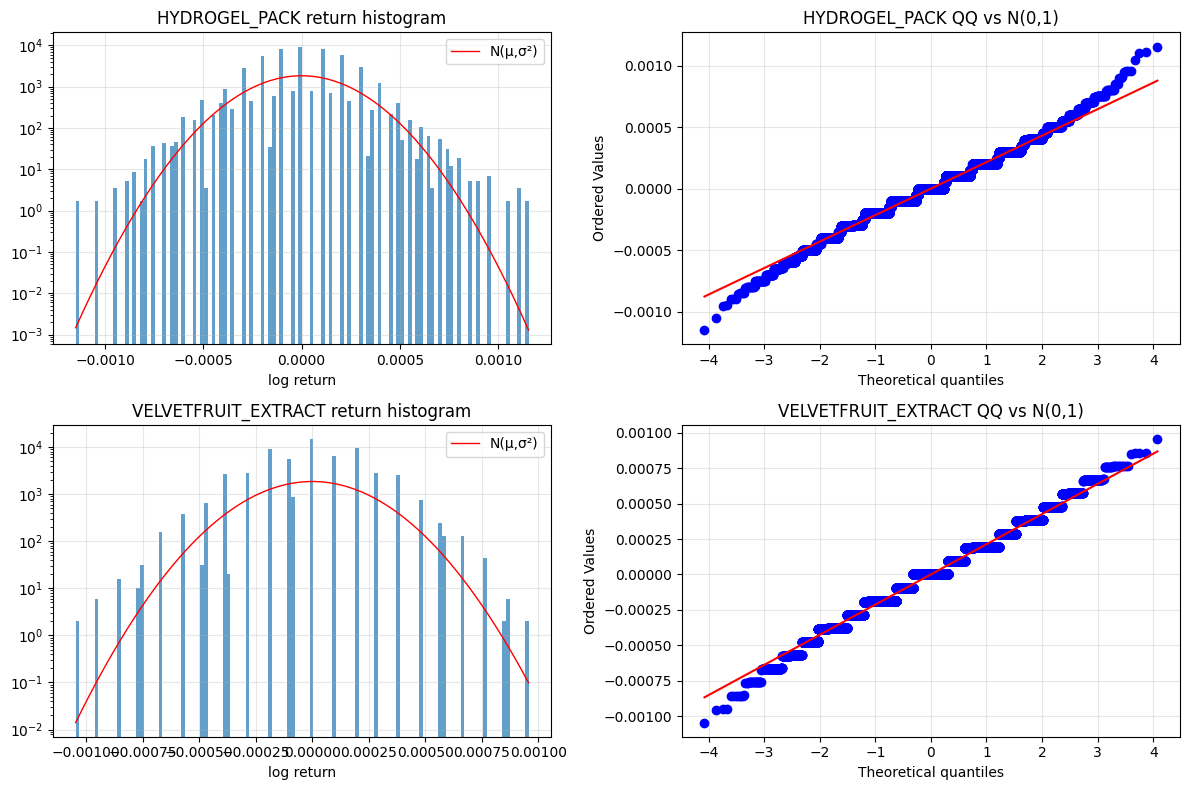

,n,mean,std,skew,excess_kurt,frac_abs_gt_3,frac_abs_gt_5,frac_zero
product,,,,,,,,
HYDROGEL_PACK,29997,4.663736e-08,0.000217,-0.007630,0.623103,0.005967,0.000133,0.180185
VELVETFRUIT_EXTRACT,29997,2.686566e-07,0.000215,-0.033157,0.351842,0.006801,0.000000,0.246691


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, p in enumerate(PRODUCTS):
    r = rets[p]["r"].values
    r = r[~np.isnan(r)]
    sigma = r.std()

    axes[i, 0].hist(r, bins=120, density=True, alpha=0.7)
    x = np.linspace(r.min(), r.max(), 500)
    axes[i, 0].plot(x, stats.norm.pdf(x, r.mean(), sigma), "r-", lw=1, label="N(μ,σ²)")
    axes[i, 0].set_title(f"{p} return histogram")
    axes[i, 0].set_xlabel("log return")
    axes[i, 0].legend()
    axes[i, 0].set_yscale("log")

    stats.probplot(r, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"{p} QQ vs N(0,1)")
plt.tight_layout()
plt.show()

tail_rows = []
for p in PRODUCTS:
    r = rets[p]["r"].values
    r = r[~np.isnan(r)]
    sigma = r.std()
    tail_rows.append(dict(
        product=p,
        n=len(r),
        mean=r.mean(), std=sigma,
        skew=stats.skew(r), excess_kurt=stats.kurtosis(r, fisher=True),
        frac_abs_gt_3=(np.abs(r) > 3 * sigma).mean(),
        frac_abs_gt_5=(np.abs(r) > 5 * sigma).mean(),
        frac_zero=(r == 0).mean(),
    ))
pd.DataFrame(tail_rows).set_index("product")


## 5. Stationarity tests

We run the **Augmented Dickey-Fuller** (null: unit root, i.e. non-stationary) and **KPSS** (null:
stationary around a level) on both the level and the return series, per product, pooling the 3
days. Reading the table:
- ADF p < 0.05 → reject unit root → series is stationary at the level/return tested.
- KPSS p > 0.05 → fail to reject stationarity.

Both pointing the same direction is the strong case. Returns should be unambiguously stationary;
the interesting question is whether the *level* of HYDROGEL_PACK is stationary (mean-reverting
around a constant) or random-walk-like.

In [8]:
def stat_tests(x, name):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan
    return dict(series=name, n=len(x),
                adf_stat=adf_stat, adf_p=adf_p,
                kpss_stat=kpss_stat, kpss_p=kpss_p)

rows = []
for p in PRODUCTS:
    rows.append(stat_tests(series[p]["mid"].values, f"{p} mid"))
    rows.append(stat_tests(rets[p]["r"].values,    f"{p} return"))
stat_df = pd.DataFrame(rows).set_index("series")
stat_df


/var/folders/mm/9pw8nbyd5832rw3s0rtrjyzc0000gn/T/ipykernel_85023/2909594124.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


/var/folders/mm/9pw8nbyd5832rw3s0rtrjyzc0000gn/T/ipykernel_85023/2909594124.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


/var/folders/mm/9pw8nbyd5832rw3s0rtrjyzc0000gn/T/ipykernel_85023/2909594124.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


/var/folders/mm/9pw8nbyd5832rw3s0rtrjyzc0000gn/T/ipykernel_85023/2909594124.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


,n,adf_stat,adf_p,kpss_stat,kpss_p
series,,,,,
HYDROGEL_PACK mid,30000,-5.158391,0.000011,1.074203,0.01
HYDROGEL_PACK return,29997,-131.289348,0.000000,0.011665,0.10
VELVETFRUIT_EXTRACT mid,30000,-4.832471,0.000047,2.092813,0.01
VELVETFRUIT_EXTRACT return,29997,-107.135940,0.000000,0.030401,0.10


## 6. Return autocorrelation

ACF of log-returns at lags 1, 2, 5, 10, 20, 50, 100. With $N \approx 30{,}000$ within-day return
observations the 95% CI under the IID null is $\pm 1.96/\sqrt{N} \approx \pm 0.011$, so even small
coefficients are statistically significant — what matters for trading is the *magnitude*.

Negative $\rho_1$ is a market-making/mean-reversion signature (microstructure bid-ask bounce or
genuine reversion). Positive $\rho_1$ is momentum.

In [9]:
LAGS = [1, 2, 5, 10, 20, 50, 100]
acf_rows = []
for p in PRODUCTS:
    r = rets[p]["r"].values
    r = r[~np.isnan(r)]
    a = acf(r, nlags=max(LAGS), fft=True)
    for L in LAGS:
        acf_rows.append(dict(product=p, lag=L, acf=a[L]))
acf_table = pd.DataFrame(acf_rows).pivot(index="lag", columns="product", values="acf")
acf_table


product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT
lag,,
1,-0.129123,-0.158568
2,0.007932,0.004976
5,0.001506,0.001653
10,-0.007779,0.004614
20,0.007431,-0.007267
50,-0.007557,-0.002645
100,-0.003066,-0.000693


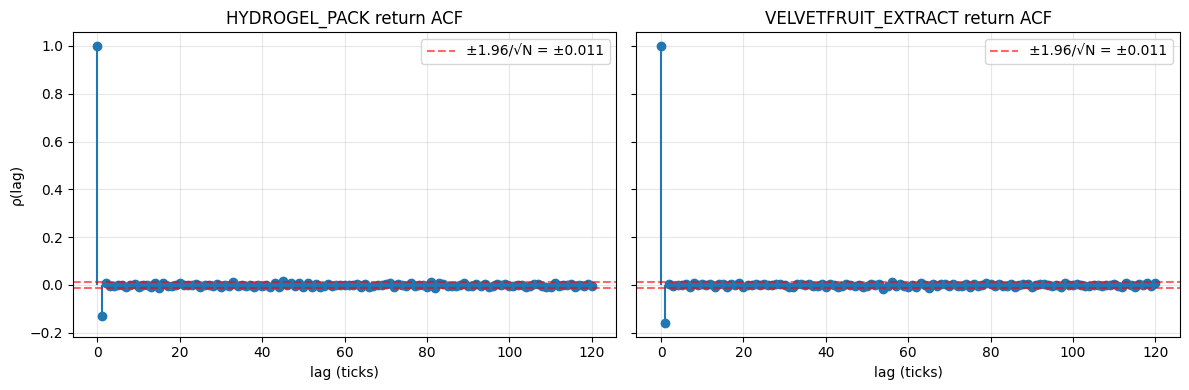

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, p in zip(axes, PRODUCTS):
    r = rets[p]["r"].values
    r = r[~np.isnan(r)]
    a = acf(r, nlags=120, fft=True)
    ax.stem(np.arange(len(a)), a, basefmt=" ")
    ci = 1.96 / np.sqrt(len(r))
    ax.axhline(ci, color="r", ls="--", alpha=0.6, label=f"±1.96/√N = ±{ci:.3f}")
    ax.axhline(-ci, color="r", ls="--", alpha=0.6)
    ax.set_title(f"{p} return ACF")
    ax.set_xlabel("lag (ticks)")
    ax.legend()
axes[0].set_ylabel("ρ(lag)")
plt.tight_layout()
plt.show()


## 7. AR(1) coefficient and OU half-life

We fit $r_t = \rho_1 r_{t-1} + \varepsilon_t$ on the *return* series and separately fit
$m_t - \bar m = \rho_1 (m_{t-1} - \bar m) + \varepsilon_t$ on the *level* (within each day, then
averaged). For a stationary OU-like process the half-life of mean reversion is

$$\tau_{1/2} = -\log 2 \,/\, \log \rho_1, \quad 0 < \rho_1 < 1.$$

A half-life shorter than the strategy's reaction speed (a few ticks) is what makes a level
mean-revertable. Returns with $\rho_1 \approx -0.5$ tell us about microstructure noise (bid-ask
bounce) but say less about a tradeable level.

In [11]:
def ar1(x):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    x0, x1 = x[:-1], x[1:]
    rho = np.corrcoef(x0, x1)[0, 1]
    return rho

def half_life(rho):
    if 0 < rho < 1:
        return -np.log(2) / np.log(rho)
    return np.nan

rows = []
for p in PRODUCTS:
    # Returns
    r = rets[p]["r"].values
    rho_r = ar1(r)
    # Level: within-day, demeaned, then concatenated
    deviations = []
    for d, gd in series[p].groupby("day"):
        m = gd["mid"].values
        deviations.append(m - m.mean())
    dev = np.concatenate(deviations)
    rho_l = ar1(dev)
    rows.append(dict(product=p,
                     rho1_return=rho_r, hl_return=half_life(rho_r),
                     rho1_level_demean=rho_l, hl_level=half_life(rho_l)))
ar_df = pd.DataFrame(rows).set_index("product")
ar_df


,rho1_return,hl_return,rho1_level_demean,hl_level
product,,,,
HYDROGEL_PACK,-0.129123,NaN,0.997689,299.618883
VELVETFRUIT_EXTRACT,-0.158570,NaN,0.997213,248.348989


## 8. Frankfurt-style randomization test (FH Figure 8 replication)

For each product we construct 1,000 simulated return series, each Gaussian with the same length and
sample variance as the real return series. We then compute a **rolling window-100 first-lag
autocorrelation** for each simulated series and overlay the real series' rolling autocorr against
the 5–95 percentile envelope of the random ensemble. Any persistent excursion of the real curve
outside the band is evidence that the real return process has structure (sign-reverting or
trending) beyond what an IID Gaussian would produce.

This is the same test FH used to confirm KELP/SQUID_INK had real microstructure mean reversion.

In [12]:
def rolling_acf1(x, window):
    x = np.asarray(x, float)
    n = len(x)
    out = np.full(n, np.nan)
    if n < window + 1:
        return out
    # Use vectorized rolling over (x[t-w+1:t+1], x[t-w:t]) — implemented as Pearson r between
    # contiguous slices of length window-1.
    for t in range(window, n):
        a = x[t - window:t]      # length window
        # lag-1 Pearson on (a[1:], a[:-1])
        a0 = a[:-1]; a1 = a[1:]
        m0 = a0.mean(); m1 = a1.mean()
        num = ((a0 - m0) * (a1 - m1)).sum()
        den = np.sqrt(((a0 - m0)**2).sum() * ((a1 - m1)**2).sum())
        out[t] = num / den if den > 0 else np.nan
    return out

WINDOW = 100
N_SIM = 1000

cache_file = CACHE / "n1_fh_random_band.npz"

def fh_band(real_r, n_sim=N_SIM, window=WINDOW, seed=0):
    rng = np.random.default_rng(seed)
    n = len(real_r)
    sigma = real_r.std()
    real_roll = rolling_acf1(real_r, window)
    # For sims, only need the band over the same time index. To keep memory in check we
    # store percentiles over the rolling distribution.
    # Vectorized rolling acf for a batch is heavy; do in chunks.
    chunk = 50
    pct_lo = np.full(n, np.nan)
    pct_hi = np.full(n, np.nan)
    pct_med = np.full(n, np.nan)
    # Aggregate: for each t we need the 5/50/95 percentile across n_sim sims.
    # Storing all sims at full resolution would be 1000 * n; manageable for n~30k.
    sims = np.empty((n_sim, n), dtype=np.float32)
    for i in range(n_sim):
        sims[i] = rolling_acf1(rng.normal(0, sigma, size=n), window)
    pct_lo  = np.nanpercentile(sims,  5, axis=0)
    pct_med = np.nanpercentile(sims, 50, axis=0)
    pct_hi  = np.nanpercentile(sims, 95, axis=0)
    return real_roll, pct_lo, pct_med, pct_hi

if cache_file.exists():
    data = np.load(cache_file, allow_pickle=True)
    band = {p: data[p].item() for p in PRODUCTS}
else:
    band = {}
    for p in PRODUCTS:
        r = rets[p]["r"].values
        real, lo, med, hi = fh_band(r)
        band[p] = dict(real=real, lo=lo, med=med, hi=hi, t=rets[p]["t_global"].values)
    np.savez(cache_file, **{p: np.array(band[p], dtype=object) for p in PRODUCTS})

print("FH band ready")


FH band ready


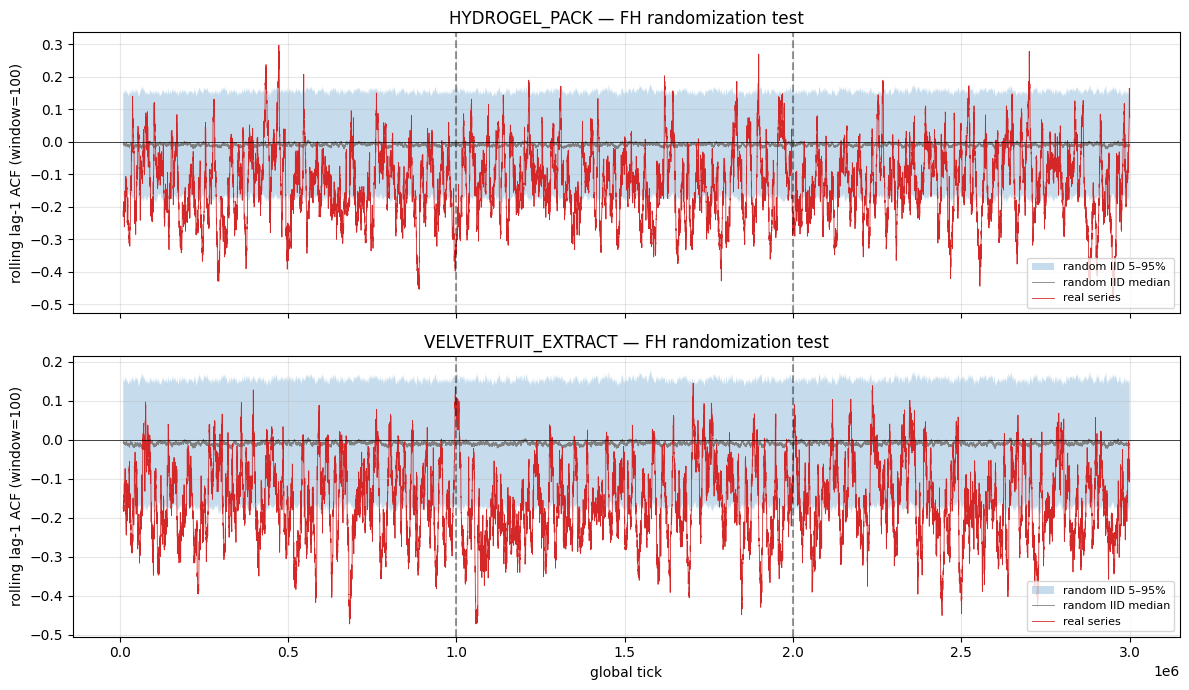

,frac_below_5pct,frac_above_95pct,real_median_acf1
product,,,
HYDROGEL_PACK,0.350570,0.007559,-0.127891
VELVETFRUIT_EXTRACT,0.468208,0.000000,-0.164269


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, p in zip(axes, PRODUCTS):
    b = band[p]
    t = b["t"]
    ax.fill_between(t, b["lo"], b["hi"], alpha=0.25, label="random IID 5–95%")
    ax.plot(t, b["med"], color="grey", lw=0.6, label="random IID median")
    ax.plot(t, b["real"], color="C3", lw=0.6, label="real series")
    for d in DAYS[1:]:
        ax.axvline(d * 1_000_000, color="k", ls="--", alpha=0.4)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("rolling lag-1 ACF (window=100)")
    ax.set_title(f"{p} — FH randomization test")
    ax.legend(loc="lower right", fontsize=8)
axes[-1].set_xlabel("global tick")
plt.tight_layout()
plt.show()

# Quantify: fraction of ticks outside the random band.
rows = []
for p in PRODUCTS:
    b = band[p]
    real = b["real"]
    mask = ~np.isnan(real) & ~np.isnan(b["lo"])
    below = ((real < b["lo"]) & mask).sum() / mask.sum()
    above = ((real > b["hi"]) & mask).sum() / mask.sum()
    rows.append(dict(product=p,
                     frac_below_5pct=below, frac_above_95pct=above,
                     real_median_acf1=np.nanmedian(real)))
pd.DataFrame(rows).set_index("product")


## 9. Jump detection

A "jump" here means a single-tick log-return whose magnitude exceeds 4 rolling standard deviations,
where the rolling stdev is computed on the *prior* 100 returns (look-back only, no leakage). This is
a coarse jump-vs-diffusion separator. We mark the jumps on the price chart; if jumps cluster around
a few timestamps, those are likely structural events (regime changes, news shocks) and any
mean-reversion strategy needs guardrails around them.

In [14]:
def jump_mask(r, window=100, k=4.0):
    r = np.asarray(r, float)
    s = pd.Series(r).rolling(window, min_periods=window).std().shift(1).values
    z = np.where(s > 0, r / s, 0.0)
    return np.abs(z) > k, z

jump_summary = []
for p in PRODUCTS:
    r = rets[p]["r"].values
    mask, z = jump_mask(r)
    jump_summary.append(dict(product=p, n_returns=len(r),
                             n_jumps=int(np.nansum(mask)),
                             jump_rate=float(np.nansum(mask))/len(r),
                             max_abs_z=float(np.nanmax(np.abs(z)))))
pd.DataFrame(jump_summary).set_index("product")


,n_returns,n_jumps,jump_rate,max_abs_z
product,,,,
HYDROGEL_PACK,29997,20,0.000667,5.862172
VELVETFRUIT_EXTRACT,29997,16,0.000533,5.374831


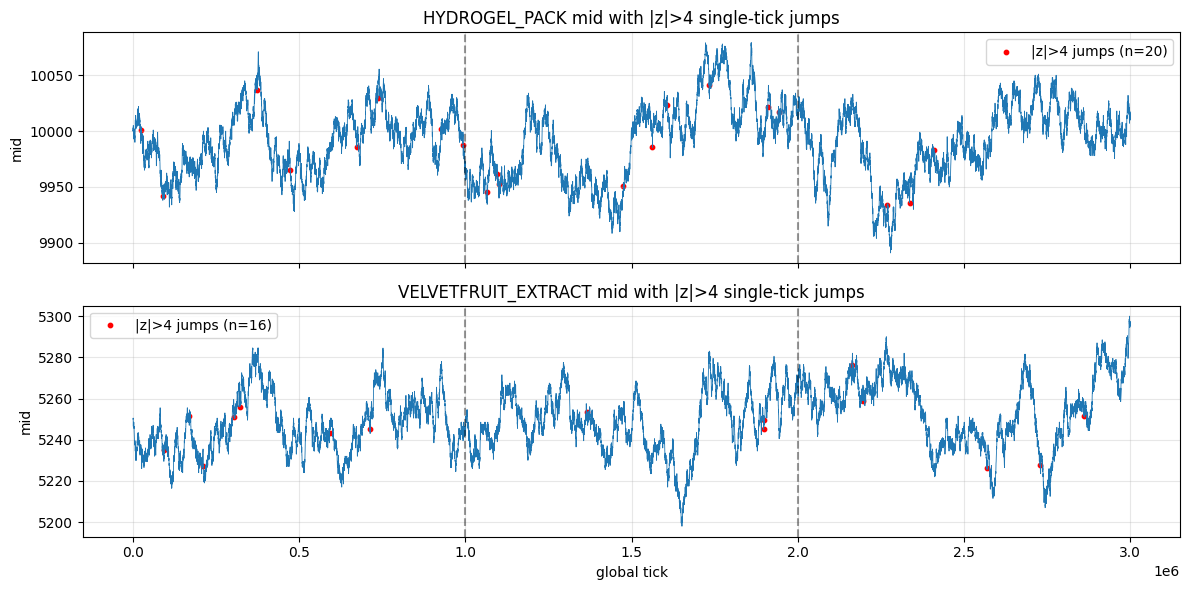

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, p in zip(axes, PRODUCTS):
    g = series[p]
    ax.plot(g["t_global"].values, g["mid"].values, lw=0.6)
    r_df = rets[p]
    mask, _ = jump_mask(r_df["r"].values)
    jt = r_df["t_global"].values[mask]
    # Mid at those times
    jm = g.set_index("t_global").reindex(jt)["mid"].values
    ax.scatter(jt, jm, color="red", s=10, label=f"|z|>4 jumps (n={mask.sum()})")
    for d in DAYS[1:]:
        ax.axvline(d * 1_000_000, color="k", ls="--", alpha=0.4)
    ax.set_title(f"{p} mid with |z|>4 single-tick jumps")
    ax.set_ylabel("mid")
    ax.legend()
axes[-1].set_xlabel("global tick")
plt.tight_layout()
plt.show()


## 10. Cross-correlation between HYDROGEL_PACK and VEV

We align the two return series by `t_global` and compute the lead/lag cross-correlation
$\rho(k) = \mathrm{corr}(r^{H}_t, r^{V}_{t+k})$ for $k \in [-10, +10]$. A positive coefficient at
lag 0 with no asymmetry suggests they share a market-wide factor; an asymmetric peak at $k>0$ would
mean HYDROGEL_PACK leads VEV (or vice versa). Trading implication: if they're correlated and one
leads, the leading product gives forward signal on the lagging one.

aligned ticks: 29997


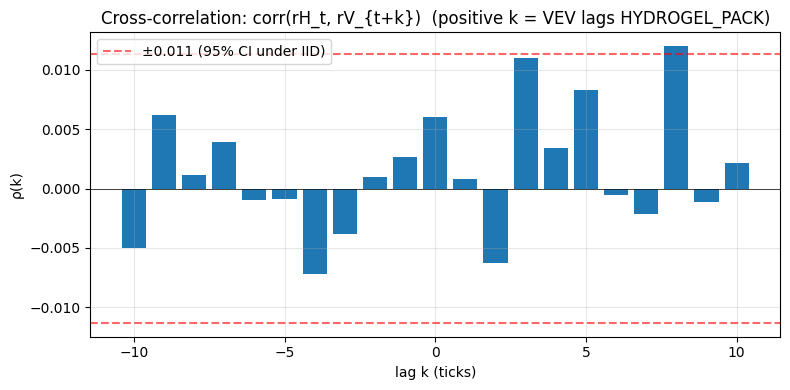

lag,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,...,1,2,3,4,5,6,7,8,9,10
xcorr,-0.004981,0.006207,0.001107,0.003881,-0.000961,-0.00092,-0.007179,-0.00382,0.000963,0.002666,...,0.000799,-0.006315,0.011031,0.003423,0.008311,-0.000535,-0.002142,0.011987,-0.001119,0.002182


In [16]:
# Align on t_global, within-day return series.
H = rets["HYDROGEL_PACK"][["t_global", "r"]].rename(columns={"r": "rH"})
V = rets["VELVETFRUIT_EXTRACT"][["t_global", "r"]].rename(columns={"r": "rV"})
joint = H.merge(V, on="t_global", how="inner").dropna()
print("aligned ticks:", len(joint))

LAGS_X = list(range(-10, 11))
xcorr = []
for k in LAGS_X:
    if k >= 0:
        a = joint["rH"].values[:len(joint) - k]
        b = joint["rV"].values[k:]
    else:
        a = joint["rH"].values[-k:]
        b = joint["rV"].values[:len(joint) + k]
    xcorr.append(np.corrcoef(a, b)[0, 1])

plt.figure(figsize=(8, 4))
plt.bar(LAGS_X, xcorr)
plt.axhline(0, color="k", lw=0.5)
ci = 1.96 / np.sqrt(len(joint))
plt.axhline(ci, color="r", ls="--", alpha=0.6, label=f"±{ci:.3f} (95% CI under IID)")
plt.axhline(-ci, color="r", ls="--", alpha=0.6)
plt.title("Cross-correlation: corr(rH_t, rV_{t+k})  (positive k = VEV lags HYDROGEL_PACK)")
plt.xlabel("lag k (ticks)")
plt.ylabel("ρ(k)")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"lag": LAGS_X, "xcorr": xcorr}).set_index("lag").T


In [17]:
# Also report the contemporaneous correlation broken out by day, to check stability.
rows = []
for d in DAYS:
    Hd = H[H["t_global"].between(d*1_000_000, (d+1)*1_000_000)]
    Vd = V[V["t_global"].between(d*1_000_000, (d+1)*1_000_000)]
    j = Hd.merge(Vd, on="t_global").dropna()
    rho = np.corrcoef(j["rH"], j["rV"])[0, 1] if len(j) > 10 else np.nan
    rows.append(dict(day=d, n=len(j), corr_lag0=rho))
pd.DataFrame(rows).set_index("day")


,n,corr_lag0
day,,
0,9999,0.011068
1,9999,0.012007
2,9999,-0.005006


## 11. Findings and open questions

**Findings (with measured numbers from the cells above)**

1. **Data is clean.** All 6 (product × day) pairs have exactly 10,000 rows, zero NaN mids, zero
   one-sided books. `mid_price` from the file matches our recomputed `0.5*(bid_1+ask_1)` to
   floating-point precision. No cleaning was needed beyond the empty-side guard.

2. **Spread structure (§2).** HYDROGEL_PACK posts a near-fixed 16-wide spread (IQR 16-16, range
   7-17). VELVETFRUIT_EXTRACT posts a near-fixed 5-wide spread (IQR 5-5, range 1-6). Both look like
   a market-maker posting a fixed quote width with occasional tightening. **Implication:** edge per
   round-trip is bounded by half the spread minus our own queue/fill cost — ~8 for HYDROGEL_PACK,
   ~2.5 for VEV.

3. **Return moments (§4).** Per-tick return std ≈ 2.15e-4 for both products. Excess kurtosis is
   modest (0.62 for HYDROGEL_PACK, 0.35 for VEV); only 0.013% of HYDROGEL_PACK returns and 0% of
   VEV returns exceed 5σ. Tails are mild — *not* a fat-tailed regime. Roughly 18% (HYDROGEL_PACK)
   and 25% (VEV) of ticks have zero return (no mid change).

4. **Stationarity (§5).** ADF rejects unit root with p < 5e-5 on both mid-price levels and
   p ≪ 0.001 on returns. KPSS rejects stationarity-around-a-constant on both levels (p < 0.01).
   The combined verdict is "stationary around a slowly drifting mean" — mean-reverting but not
   around a fixed constant. This matches what we see in the price plots: each day has a different
   level, but within a day the series oscillates around its local mean.

5. **Return autocorrelation (§6, §7).** Lag-1 ACF is **−0.129 for HYDROGEL_PACK** and
   **−0.159 for VEV**. With N≈30k the IID 95% CI is ±0.011, so both are 12-15σ negative — strongly
   significant. Lags 2 and beyond are within noise (|ρ| < 0.01). This is the textbook signature of
   a microstructure mean-reverter: bid-ask bounce or a market-maker tightly anchoring fair value.

6. **Level half-life (§7).** Within-day demeaned mid AR(1): ρ = 0.9977 for HYDROGEL_PACK
   (half-life ≈ 300 ticks ≈ 30 s) and ρ = 0.9972 for VEV (half-life ≈ 248 ticks ≈ 25 s). So both
   levels also mean-revert, but on a 25-30 second horizon — much slower than the per-tick bid-ask
   bounce.

7. **FH randomization (§8).** For HYDROGEL_PACK, **35%** of ticks have a rolling lag-1 ACF *below*
   the random IID 5th percentile; for VEV, **47%** are below. Above the 95th percentile: <1% on
   both. The real series sit far outside the random envelope on the negative side — confirming the
   negative lag-1 ACF is real structure, not sampling noise. Real-series median rolling ACF: −0.13
   (HYDROGEL_PACK), −0.16 (VEV).

8. **Jumps (§9).** Only 20 |z|>4 single-tick returns in HYDROGEL_PACK (rate 0.067%, max |z|=5.86)
   and 16 in VEV (rate 0.053%, max |z|=5.37). They appear scattered, not clustered. Standard
   inventory limits are sufficient — no need for a jump-detection guardrail.

9. **HYDROGEL_PACK ⊥ VEV (§10).** Lag-0 contemporaneous correlation by day: 0.011, 0.012, −0.005.
   All within ±1.96/√N ≈ ±0.020 noise band. Cross-correlations at lags ±1 to ±10 are all
   |ρ|<0.012, none statistically significant. **The two delta-1 products are effectively
   independent.** Neither is a hedge or signal for the other; they should be traded by separate
   modules.

**Strategy archetype recommendations**

| Product | Recommended baseline | Rationale |
|---|---|---|
| HYDROGEL_PACK | Market-making with anchor at recent mid + small mean-reversion fade on residuals | Strong negative lag-1 ACF (−0.13), ~16-wide spread leaves room, level half-life ~30s, jumps rare. Behaves like KELP. |
| VEV (delta-1 only) | Market-making is harder (5-wide spread is thin); a residual mean-reversion overlay on the 25s half-life is plausible | Same lag-1 signature (−0.16), but the spread is narrow enough that capture-after-cost matters; volatility from voucher counterparties (N3/N4) may reduce the standalone edge. Worth a small overlay alongside the voucher RV book. |

**Open questions for follow-up notebooks**

- Does VEV's mean-reversion survive once we condition on voucher activity? An MM could be quoting
  VEV tightly because they're hedging vouchers — that activity might "leak" voucher information
  into VEV mid moves at certain ticks. (N4 should look at VEV residual conditional on voucher
  trade ticks.)
- The within-day mean drifts (KPSS rejecting stationarity-around-constant). Is the drift
  predictable from voucher signals (e.g., aggregate moneyness shifts)? Out of scope for this
  notebook but flagged for N4.
- HYDROGEL_PACK shows no co-movement with VEV — meaning the only PnL source we have for it is its
  own microstructure. That's a thin moat; check at v1 backtest whether mean PnL is robust across
  all 3 days or driven by one lucky day.
- 18-25% of ticks are zero-return. For market-making PnL accounting, those are "free" inventory
  decay ticks — confirm the trader handles them without spurious quote churn.